## Application examples notebook

application_examples.ipynb demonstrates how to use iberian-day-ahead-market-simulator with real OMIE and ENTSO-E data for a full day market session.

The notebook covers:
1. Reproducing the day-ahead clearing process with real bids and interconnection data.
   1. Comparing simulated clearing prices (ES/PT) against real OMIE market prices.
   2. Comparing simulated ES-PT transmission against real interconnection occupation.
2. Scenario analysis by removing one bidding group.
3. Scenario analysis by removing MIC conditions.
4. Scenario analysis changing prices of a bidding unit
5. Scenario analysis by modifying wind production volumes to evaluate market impact.
6. Scenario analysis by modifying solar production volumes to evaluate market impact.


## Data used

The notebook is configured for the day 2025-06-21 and expects the following files under data:
- CAB
- DET
- capacidad_inter_pbc
- marginalpdbc
- ENTSOE_FR_Clearing_prices.csv
- LISTA_UNIDADES.XLS for the last two scenarios

To run other dates, update the DATE variable in the notebook and provide matching files (or download them with download_omie_data.ipynb).

## Requirements

Install the package from pip before running:

```bash
pip install iberian-day-ahead-market-simulator
```

Install the solver you want to use (Gurobi or HiGHS):

```bash
pip install gurobipy  # for Gurobi, make sure you have a valid license and the software installed
pip install highspy  # for HiGHS
```


If you also run notebook cells that read Excel unit lists, make sure openpyxl and xlrd are available:

```bash
pip install openpyxl xlrd
```

## How to run

1. Open application_examples.ipynb in Jupyter or VS Code.
2. Verify DATE and input file paths.
3. Run all cells from top to bottom.
4. Review plots and comparison tables for prices and ES-PT flows across the different use cases.

# Constants, imports and general variables

In [1]:
DATE = "2025-06-21"
SOLVER = "highs"  # "gurobi" or "highs"
N_JOBS = 14  # Number of parallel processes for scenario analysis

In [2]:
DATE_YYYYMMDD = DATE.replace("-", "")
DET_FILEPATH = f"data/DET/DET_{DATE_YYYYMMDD}.1"
CAB_FILEPATH = f"data/CAB/CAB_{DATE_YYYYMMDD}.1"
CAPACIDAD_INTER_PBC_FILEPATH = (
    f"data/capacidad_inter_pbc/capacidad_inter_pbc_{DATE_YYYYMMDD}.1"
)
MARGINALPDBC_FILEPATH = f"data/marginalpdbc/marginalpdbc_{DATE_YYYYMMDD}.1"
FRANCE_DAY_AHEAD_PRICES_FILEPATH = "data/ENTSOE_FR_Clearing_prices.csv"

In [3]:
import pandas as pd
from matplotlib import pyplot as plt

from iberian_day_ahead_market_simulator import (
    parse_price_france_from_entsoe_file,
    parse_capacidad_inter_file,
    run_iberian_day_ahead_market_simulator,
    parse_cab_file,
    parse_det_file,
    parse_marginalpdbc_file,
    plot_clearing_prices,
    plot_spain_portugal_transmissions,
    cols,
)

In [4]:
date = pd.to_datetime(DATE)

det_df = parse_det_file(DET_FILEPATH)
cab_df = parse_cab_file(CAB_FILEPATH)

Periodo 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: data/DET/DET_20250621.1


21 2776.25


# Parse France day-ahead prices from ENTSO-E file

In [5]:
france_day_ahead_prices_full_year = parse_price_france_from_entsoe_file(
    FRANCE_DAY_AHEAD_PRICES_FILEPATH
)
france_day_ahead_prices = france_day_ahead_prices_full_year.query(
    f"{cols.DATE_SESION} == @date"
).copy()

Detected quarter-hourly data in France prices, but use_qh_frequency is False. Processing as hourly data.


# Use case 1: reproduce clearing process with real data

## Run simulation and plot results

In [6]:
results = run_iberian_day_ahead_market_simulator(
    det=DET_FILEPATH,
    cab=CAB_FILEPATH,
    capacidad_inter_pbc=CAPACIDAD_INTER_PBC_FILEPATH,
    france_day_ahead_prices=france_day_ahead_prices,
    n_jobs=N_JOBS,
    solver_factory_type=SOLVER,
)

Periodo 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: data/DET/DET_20250621.1


21 2776.25


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


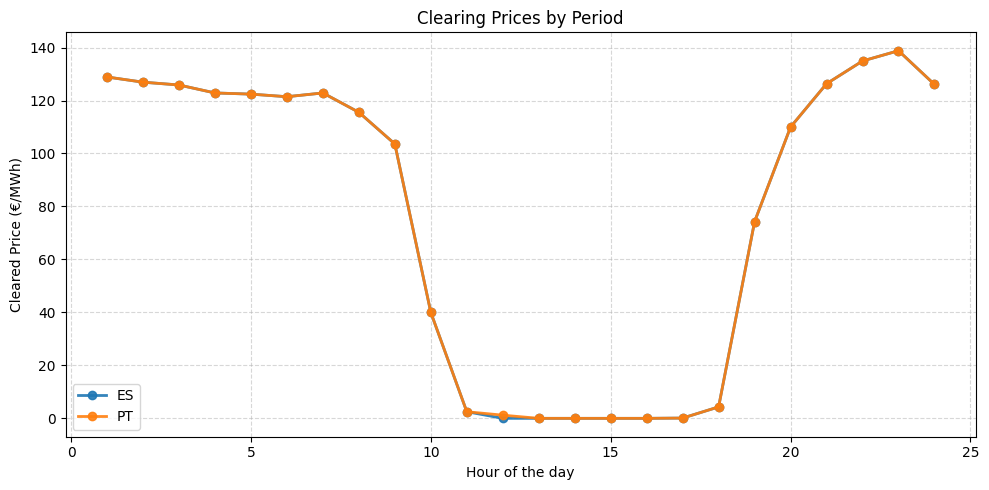

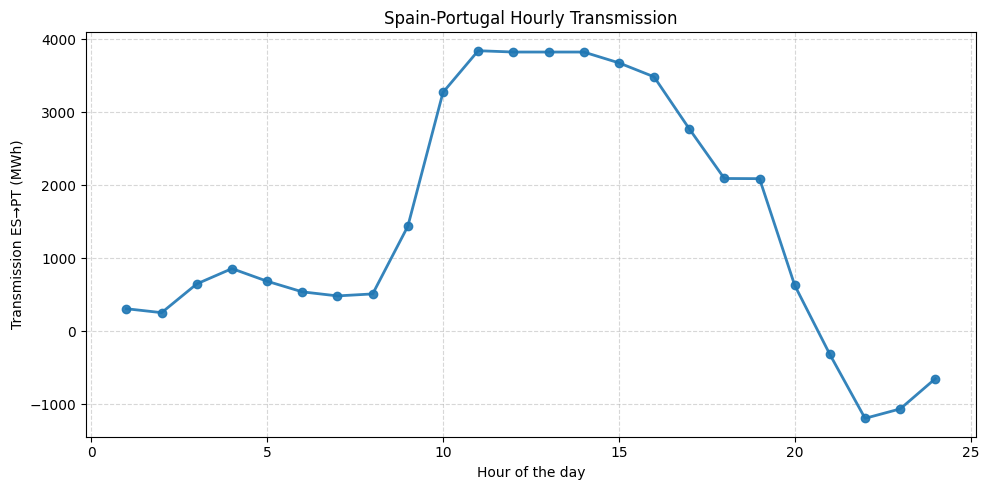

In [7]:
plot_clearing_prices(results)

plot_spain_portugal_transmissions(results)

## Compare with real data

,int_period,float_cleared_price_simulated,cat_bidding_zone,float_cleared_price_real,error_float_cleared_price
0,1,128.89,ES,128.89,0.0
1,2,126.93,ES,126.93,0.0
2,3,125.87,ES,125.87,0.0
3,4,122.86,ES,122.86,0.0
4,5,122.42,ES,122.42,0.0
5,6,121.44,ES,121.44,0.0
6,7,122.86,ES,122.86,0.0
7,8,115.56,ES,115.56,0.0
8,9,103.60,ES,103.60,0.0
9,10,40.00,ES,40.00,0.0


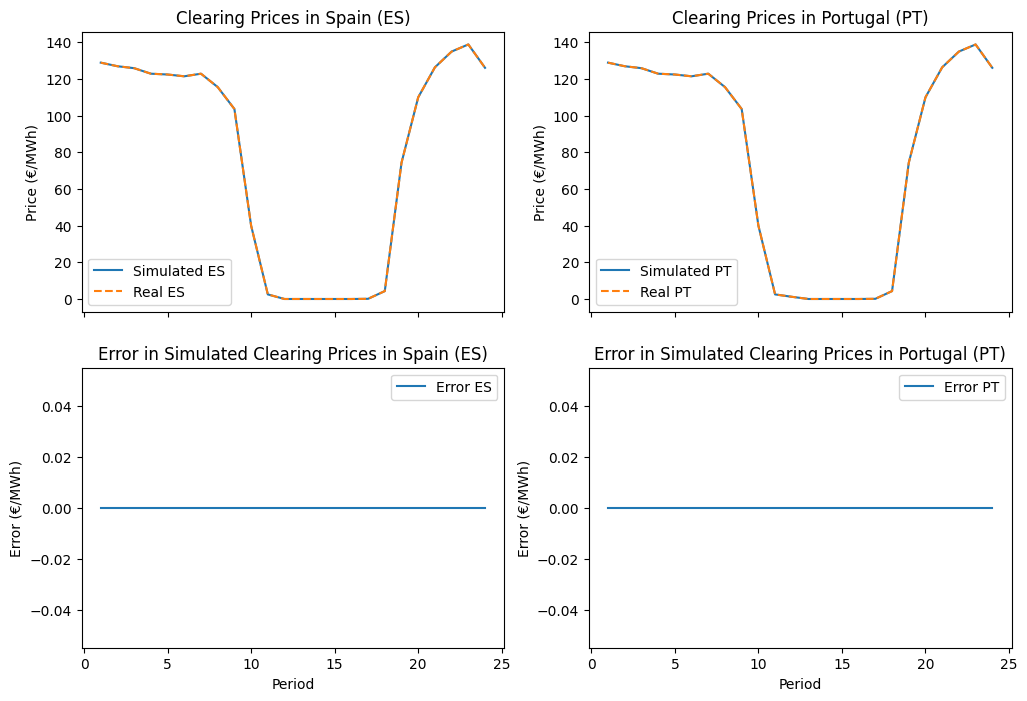

In [8]:
results_clearing_prices = results["clearing_prices"]
real_clearing_prices = parse_marginalpdbc_file(MARGINALPDBC_FILEPATH)

#####################

clearing_prices_df = results_clearing_prices.merge(
    real_clearing_prices,
    on=[cols.INT_PERIOD, cols.CAT_BIDDING_ZONE],
    suffixes=("_simulated", "_real"),
)

clearing_prices_df[f"error_{cols.FLOAT_CLEARED_PRICE}"] = (
    clearing_prices_df[f"{cols.FLOAT_CLEARED_PRICE}_simulated"]
    - clearing_prices_df[f"{cols.FLOAT_CLEARED_PRICE}_real"]
).round(2)

display(clearing_prices_df)

clearing_prices_df_es = clearing_prices_df.query(
    f"{cols.CAT_BIDDING_ZONE} == 'ES'"
).copy()
clearing_prices_df_pt = clearing_prices_df.query(
    f"{cols.CAT_BIDDING_ZONE} == 'PT'"
).copy()

#####################

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True)
axes = axes.flatten()
axes[0].plot(
    clearing_prices_df_es[cols.INT_PERIOD],
    clearing_prices_df_es[cols.FLOAT_CLEARED_PRICE + "_simulated"],
    label="Simulated ES",
)
axes[0].plot(
    clearing_prices_df_es[cols.INT_PERIOD],
    clearing_prices_df_es[cols.FLOAT_CLEARED_PRICE + "_real"],
    label="Real ES",
    linestyle="dashed",
)
axes[0].set_title("Clearing Prices in Spain (ES)")
axes[0].set_ylabel("Price (€/MWh)")
axes[0].legend()

axes[1].plot(
    clearing_prices_df_pt[cols.INT_PERIOD],
    clearing_prices_df_pt[cols.FLOAT_CLEARED_PRICE + "_simulated"],
    label="Simulated PT",
)
axes[1].plot(
    clearing_prices_df_pt[cols.INT_PERIOD],
    clearing_prices_df_pt[cols.FLOAT_CLEARED_PRICE + "_real"],
    label="Real PT",
    linestyle="dashed",
)
axes[1].set_title("Clearing Prices in Portugal (PT)")
axes[1].set_ylabel("Price (€/MWh)")
axes[1].legend()

axes[2].plot(
    clearing_prices_df_es[cols.INT_PERIOD],
    clearing_prices_df_es[f"error_{cols.FLOAT_CLEARED_PRICE}"],
    label="Error ES",
)
axes[2].set_title("Error in Simulated Clearing Prices in Spain (ES)")
axes[2].set_xlabel("Period")
axes[2].set_ylabel("Error (€/MWh)")
axes[2].legend()

axes[3].plot(
    clearing_prices_df_pt[cols.INT_PERIOD],
    clearing_prices_df_pt[f"error_{cols.FLOAT_CLEARED_PRICE}"],
    label="Error PT",
)
axes[3].set_title("Error in Simulated Clearing Prices in Portugal (PT)")
axes[3].set_xlabel("Period")
axes[3].set_ylabel("Error (€/MWh)")
axes[3].legend()

,Transmision_ES_PT_simulated,int_period,Transmision_ES_PT_real,error_transmission
0,307.1,1,307.1,0.0
1,253.3,2,253.3,0.0
2,647.8,3,647.8,0.0
3,857.2,4,857.2,0.0
4,683.8,5,683.8,0.0
5,538.5,6,538.5,0.0
6,482.9,7,482.9,0.0
7,510.2,8,510.2,-0.0
8,1437.5,9,1437.5,-0.0
9,3272.4,10,3272.4,-0.0


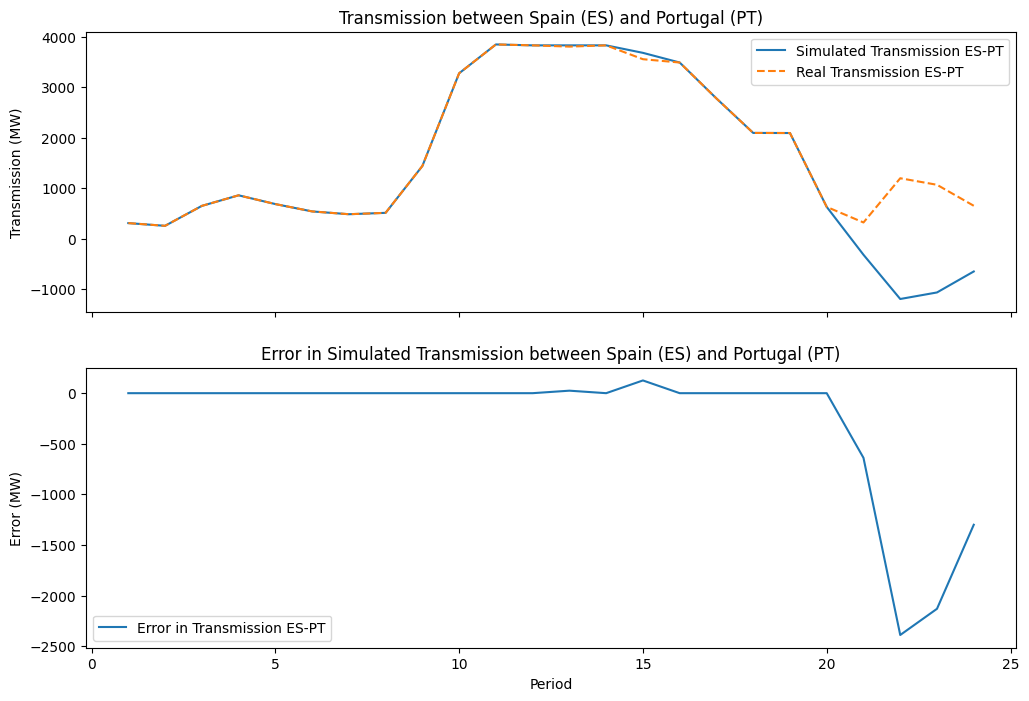

In [9]:
results_spain_portugal_transmissions = results["spain_portugal_transmissions"]
real_spain_portugal_transmissions = parse_capacidad_inter_file(
    CAPACIDAD_INTER_PBC_FILEPATH, "PT"
).eval(
    f"Transmision_ES_PT = {cols.FLOAT_EXPORT_CAPACITY_OCCUPATION} - {cols.FLOAT_IMPORT_CACACITY_OCCUPATION}"
)

transmissions_df = results_spain_portugal_transmissions.merge(
    real_spain_portugal_transmissions[[cols.INT_PERIOD, "Transmision_ES_PT"]],
    right_on=cols.INT_PERIOD,
    left_index=True,
    suffixes=("_simulated", "_real"),
)
transmissions_df["error_transmission"] = (
    transmissions_df["Transmision_ES_PT_simulated"]
    - transmissions_df["Transmision_ES_PT_real"]
).round(2)

display(transmissions_df)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
axes[0].plot(
    transmissions_df[cols.INT_PERIOD],
    transmissions_df["Transmision_ES_PT_simulated"],
    label="Simulated Transmission ES-PT",
)
axes[0].plot(
    transmissions_df[cols.INT_PERIOD],
    transmissions_df["Transmision_ES_PT_real"],
    label="Real Transmission ES-PT",
    linestyle="dashed",
)
axes[0].set_title("Transmission between Spain (ES) and Portugal (PT)")
axes[0].set_ylabel("Transmission (MW)")
axes[0].legend()

axes[1].plot(
    transmissions_df[cols.INT_PERIOD],
    transmissions_df["error_transmission"],
    label="Error in Transmission ES-PT",
)
axes[1].set_title(
    "Error in Simulated Transmission between Spain (ES) and Portugal (PT)"
)
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Error (MW)")
axes[1].legend()

# Use case 2: delete a group and see how it affects the clearing process

## Parse Cabecera and Detalle files

In [10]:
det_df = parse_det_file(DET_FILEPATH)
cab_df = parse_cab_file(CAB_FILEPATH)

display("DET DataFrame:")
display(det_df)
display("CAB DataFrame:")
display(cab_df)

Periodo 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: data/DET/DET_20250621.1


21 2776.25


'DET DataFrame:'

,date_sesion,id_order,int_period,int_num_block,int_num_suborder,int_num_excl_group,float_bid_price,float_bid_power,float_mav,float_mar
0,2025-06-21,9511814,1,0,1,0,1000.0,0.1,0.0,0.0
1,2025-06-21,9511814,2,0,1,0,1000.0,0.1,0.0,0.0
2,2025-06-21,9511814,3,0,1,0,1000.0,0.1,0.0,0.0
3,2025-06-21,9511814,4,0,1,0,1000.0,0.1,0.0,0.0
4,2025-06-21,9511814,5,0,1,0,1000.0,0.1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
66625,2025-06-21,9734118,22,0,2,0,0.0,129.5,0.0,0.0
66626,2025-06-21,9734118,23,0,1,0,-11.1,39.5,0.0,0.0
66627,2025-06-21,9734118,23,0,2,0,0.0,123.0,0.0,0.0
66628,2025-06-21,9734118,24,0,1,0,-11.1,37.1,0.0,0.0


'CAB DataFrame:'

,date_sesion,id_order,id_unidad,cat_buy_sell,float_mic,float_max_power
0,2025-06-21,9511814,IGNVD46,V,0.0,12.2
1,2025-06-21,9511825,IGNVD68,V,0.0,49.8
2,2025-06-21,9511833,IGNVD72,V,0.0,136.5
3,2025-06-21,9511846,IGNVD83,V,0.0,44.1
4,2025-06-21,9511859,IGVD105,V,0.0,3.5
...,...,...,...,...,...,...
2529,2025-06-21,9739171,RECRC21,C,0.0,3.9
2530,2025-06-21,9739172,RECRC22,C,0.0,2.5
2531,2025-06-21,9739173,RECRC24,C,0.0,0.4
2532,2025-06-21,9739174,RECRC28,C,0.0,1.0


## Delete a group and run the simulation again

In [11]:
ID_UNIDAD = "ENDE01"
id_order = cab_df.query(f"{cols.ID_UNIDAD} == @ID_UNIDAD")[cols.ID_ORDER].iloc[0]

display(f"Orders for unit {ID_UNIDAD}: {id_order}")
det_df = det_df.query(f"{cols.ID_ORDER} != @id_order").copy()
cab_df = cab_df.query(f"{cols.ID_ORDER} != @id_order").copy()

'Orders for unit ENDE01: 9740198'

In [12]:
results_case_2 = run_iberian_day_ahead_market_simulator(
    det=det_df,
    cab=cab_df,
    capacidad_inter_pbc=CAPACIDAD_INTER_PBC_FILEPATH,
    france_day_ahead_prices=france_day_ahead_prices,
    n_jobs=N_JOBS,
    solver_factory_type=SOLVER,
)

/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


## Compare with real data

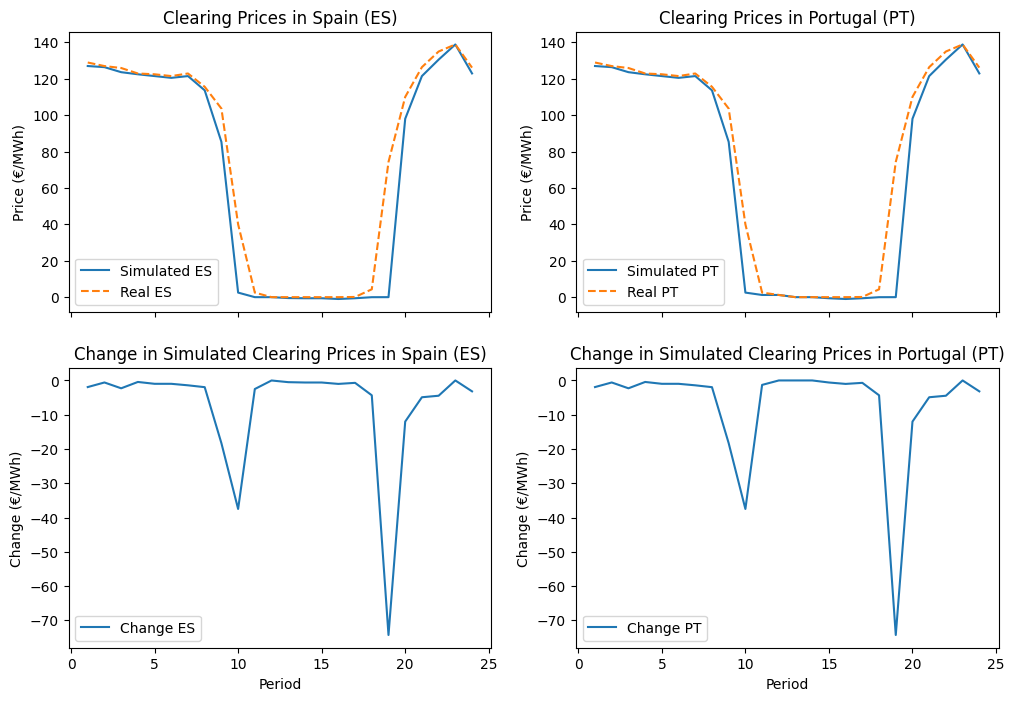

In [13]:
results_clearing_prices = results_case_2["clearing_prices"]
real_clearing_prices = parse_marginalpdbc_file(MARGINALPDBC_FILEPATH)

clearing_prices_df = results_clearing_prices.merge(
    real_clearing_prices,
    on=[cols.INT_PERIOD, cols.CAT_BIDDING_ZONE],
    suffixes=("_simulated", "_real"),
)
clearing_prices_df[f"error_{cols.FLOAT_CLEARED_PRICE}"] = (
    clearing_prices_df[f"{cols.FLOAT_CLEARED_PRICE}_simulated"]
    - clearing_prices_df[f"{cols.FLOAT_CLEARED_PRICE}_real"]
).round(2)


clearing_prices_df_es = clearing_prices_df.query(
    f"{cols.CAT_BIDDING_ZONE} == 'ES'"
).copy()
clearing_prices_df_pt = clearing_prices_df.query(
    f"{cols.CAT_BIDDING_ZONE} == 'PT'"
).copy()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True)
axes = axes.flatten()
axes[0].plot(
    clearing_prices_df_es[cols.INT_PERIOD],
    clearing_prices_df_es[cols.FLOAT_CLEARED_PRICE + "_simulated"],
    label="Simulated ES",
)
axes[0].plot(
    clearing_prices_df_es[cols.INT_PERIOD],
    clearing_prices_df_es[cols.FLOAT_CLEARED_PRICE + "_real"],
    label="Real ES",
    linestyle="dashed",
)
axes[0].set_title("Clearing Prices in Spain (ES)")
axes[0].set_ylabel("Price (€/MWh)")
axes[0].legend()

axes[1].plot(
    clearing_prices_df_pt[cols.INT_PERIOD],
    clearing_prices_df_pt[cols.FLOAT_CLEARED_PRICE + "_simulated"],
    label="Simulated PT",
)
axes[1].plot(
    clearing_prices_df_pt[cols.INT_PERIOD],
    clearing_prices_df_pt[cols.FLOAT_CLEARED_PRICE + "_real"],
    label="Real PT",
    linestyle="dashed",
)
axes[1].set_title("Clearing Prices in Portugal (PT)")
axes[1].set_ylabel("Price (€/MWh)")
axes[1].legend()

axes[2].plot(
    clearing_prices_df_es[cols.INT_PERIOD],
    clearing_prices_df_es[f"error_{cols.FLOAT_CLEARED_PRICE}"],
    label="Change ES",
)
axes[2].set_title("Change in Simulated Clearing Prices in Spain (ES)")
axes[2].set_xlabel("Period")
axes[2].set_ylabel("Change (€/MWh)")
axes[2].legend()

axes[3].plot(
    clearing_prices_df_pt[cols.INT_PERIOD],
    clearing_prices_df_pt[f"error_{cols.FLOAT_CLEARED_PRICE}"],
    label="Change PT",
)
axes[3].set_title("Change in Simulated Clearing Prices in Portugal (PT)")
axes[3].set_xlabel("Period")
axes[3].set_ylabel("Change (€/MWh)")
axes[3].legend()

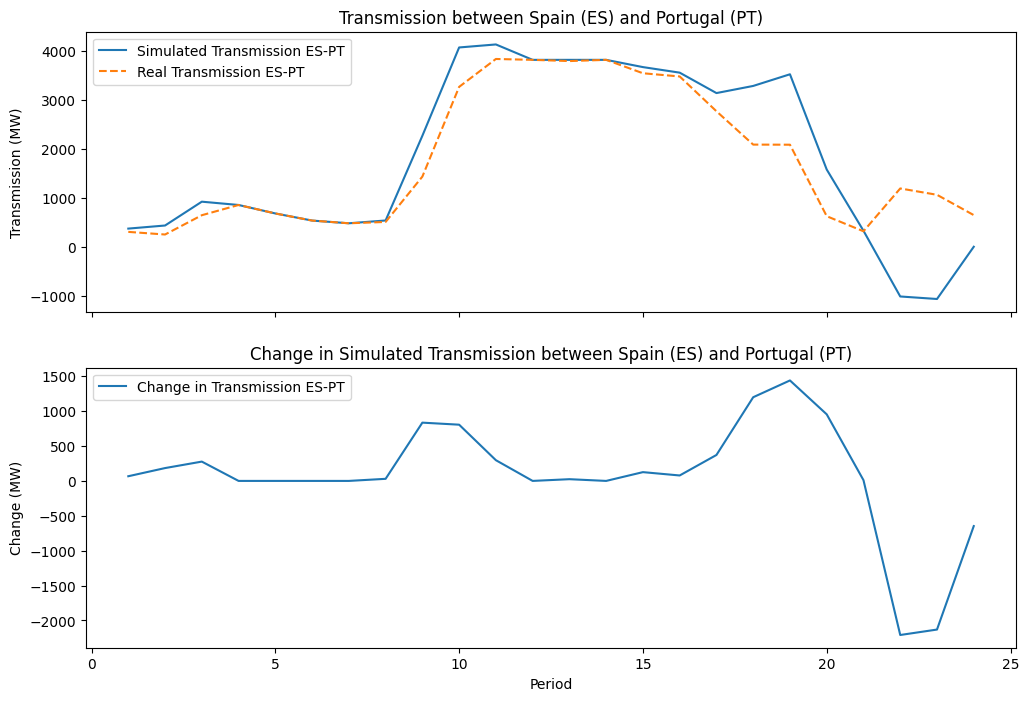

In [14]:
results_spain_portugal_transmissions = results_case_2["spain_portugal_transmissions"]
real_spain_portugal_transmissions = parse_capacidad_inter_file(
    CAPACIDAD_INTER_PBC_FILEPATH, "PT"
).eval(
    f"Transmision_ES_PT = {cols.FLOAT_EXPORT_CAPACITY_OCCUPATION} - {cols.FLOAT_IMPORT_CACACITY_OCCUPATION}"
)

transmissions_df = results_spain_portugal_transmissions.merge(
    real_spain_portugal_transmissions[[cols.INT_PERIOD, "Transmision_ES_PT"]],
    right_on=cols.INT_PERIOD,
    left_index=True,
    suffixes=("_simulated", "_real"),
)
transmissions_df["error_transmission"] = (
    transmissions_df["Transmision_ES_PT_simulated"]
    - transmissions_df["Transmision_ES_PT_real"]
).round(2)


fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
axes[0].plot(
    transmissions_df[cols.INT_PERIOD],
    transmissions_df["Transmision_ES_PT_simulated"],
    label="Simulated Transmission ES-PT",
)
axes[0].plot(
    transmissions_df[cols.INT_PERIOD],
    transmissions_df["Transmision_ES_PT_real"],
    label="Real Transmission ES-PT",
    linestyle="dashed",
)
axes[0].set_title("Transmission between Spain (ES) and Portugal (PT)")
axes[0].set_ylabel("Transmission (MW)")
axes[0].legend()

axes[1].plot(
    transmissions_df[cols.INT_PERIOD],
    transmissions_df["error_transmission"],
    label="Change in Transmission ES-PT",
)
axes[1].set_title(
    "Change in Simulated Transmission between Spain (ES) and Portugal (PT)"
)
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Change (MW)")
axes[1].legend()

# Use case 3: delete all MIC conditions and see how it affects the clearing process

## Parse Cabecera and Detalle files

In [15]:
det_df = parse_det_file(DET_FILEPATH)
cab_df = parse_cab_file(CAB_FILEPATH)

cab_df.query("float_mic > 0")

Periodo 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: data/DET/DET_20250621.1


21 2776.25


,date_sesion,id_order,id_unidad,cat_buy_sell,float_mic,float_max_power
167,2025-06-21,9702108,ABO1,V,635000.0,351.0
815,2025-06-21,9740088,ACE4,V,121098.0,379.3
816,2025-06-21,9740089,BES4,V,178794.0,400.0
817,2025-06-21,9740090,CAMGI10,V,179702.0,392.7
818,2025-06-21,9740091,CTGN1,V,200584.0,424.5
819,2025-06-21,9740093,CTGN3,V,200348.0,419.3
820,2025-06-21,9740094,MALA1,V,173446.0,421.0
821,2025-06-21,9740095,PALOS1,V,184287.0,394.1
822,2025-06-21,9740096,PALOS2,V,170060.0,395.6
823,2025-06-21,9740097,PALOS3,V,226900.0,397.8


## Delete mic condition and run the simulation again

In [16]:
cab_df["float_mic"] = 0

In [17]:
results_case_3 = run_iberian_day_ahead_market_simulator(
    det=det_df,
    cab=cab_df,
    capacidad_inter_pbc=CAPACIDAD_INTER_PBC_FILEPATH,
    france_day_ahead_prices=france_day_ahead_prices,
    n_jobs=N_JOBS,
    solver_factory_type=SOLVER,
)

/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


## Compare with real data

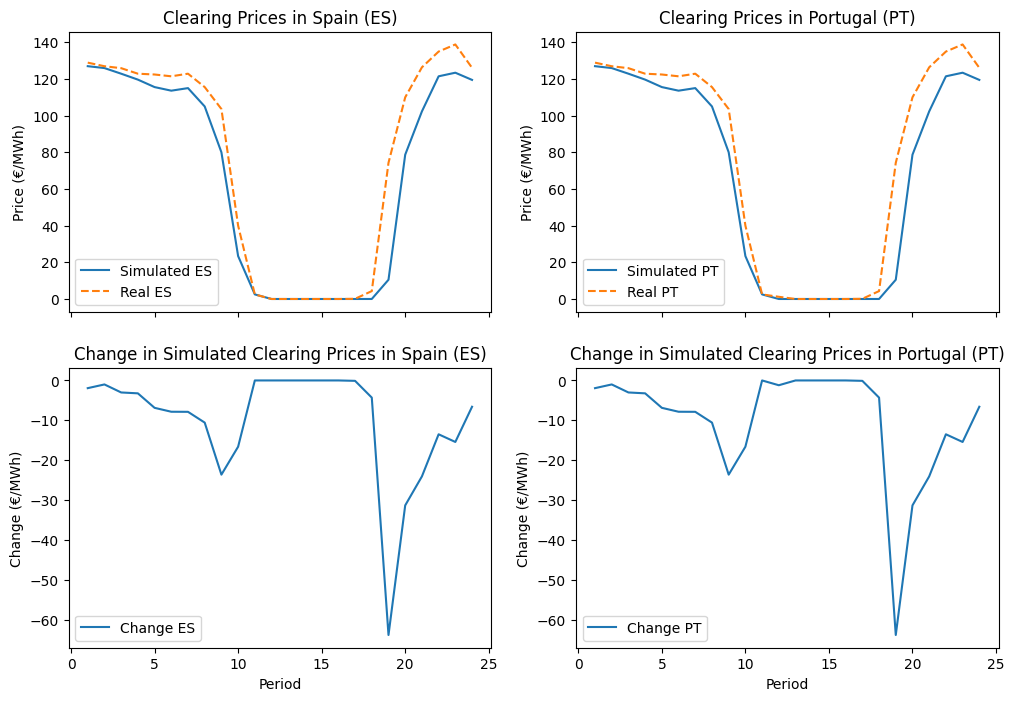

In [18]:
results_clearing_prices = results_case_3["clearing_prices"]
real_clearing_prices = parse_marginalpdbc_file(MARGINALPDBC_FILEPATH)

clearing_prices_df = results_clearing_prices.merge(
    real_clearing_prices,
    on=[cols.INT_PERIOD, cols.CAT_BIDDING_ZONE],
    suffixes=("_simulated", "_real"),
)
clearing_prices_df[f"error_{cols.FLOAT_CLEARED_PRICE}"] = (
    clearing_prices_df[f"{cols.FLOAT_CLEARED_PRICE}_simulated"]
    - clearing_prices_df[f"{cols.FLOAT_CLEARED_PRICE}_real"]
).round(2)


clearing_prices_df_es = clearing_prices_df.query(
    f"{cols.CAT_BIDDING_ZONE} == 'ES'"
).copy()
clearing_prices_df_pt = clearing_prices_df.query(
    f"{cols.CAT_BIDDING_ZONE} == 'PT'"
).copy()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True)
axes = axes.flatten()
axes[0].plot(
    clearing_prices_df_es[cols.INT_PERIOD],
    clearing_prices_df_es[cols.FLOAT_CLEARED_PRICE + "_simulated"],
    label="Simulated ES",
)
axes[0].plot(
    clearing_prices_df_es[cols.INT_PERIOD],
    clearing_prices_df_es[cols.FLOAT_CLEARED_PRICE + "_real"],
    label="Real ES",
    linestyle="dashed",
)
axes[0].set_title("Clearing Prices in Spain (ES)")
axes[0].set_ylabel("Price (€/MWh)")
axes[0].legend()

axes[1].plot(
    clearing_prices_df_pt[cols.INT_PERIOD],
    clearing_prices_df_pt[cols.FLOAT_CLEARED_PRICE + "_simulated"],
    label="Simulated PT",
)
axes[1].plot(
    clearing_prices_df_pt[cols.INT_PERIOD],
    clearing_prices_df_pt[cols.FLOAT_CLEARED_PRICE + "_real"],
    label="Real PT",
    linestyle="dashed",
)
axes[1].set_title("Clearing Prices in Portugal (PT)")
axes[1].set_ylabel("Price (€/MWh)")
axes[1].legend()

axes[2].plot(
    clearing_prices_df_es[cols.INT_PERIOD],
    clearing_prices_df_es[f"error_{cols.FLOAT_CLEARED_PRICE}"],
    label="Change ES",
)
axes[2].set_title("Change in Simulated Clearing Prices in Spain (ES)")
axes[2].set_xlabel("Period")
axes[2].set_ylabel("Change (€/MWh)")
axes[2].legend()

axes[3].plot(
    clearing_prices_df_pt[cols.INT_PERIOD],
    clearing_prices_df_pt[f"error_{cols.FLOAT_CLEARED_PRICE}"],
    label="Change PT",
)
axes[3].set_title("Change in Simulated Clearing Prices in Portugal (PT)")
axes[3].set_xlabel("Period")
axes[3].set_ylabel("Change (€/MWh)")
axes[3].legend()

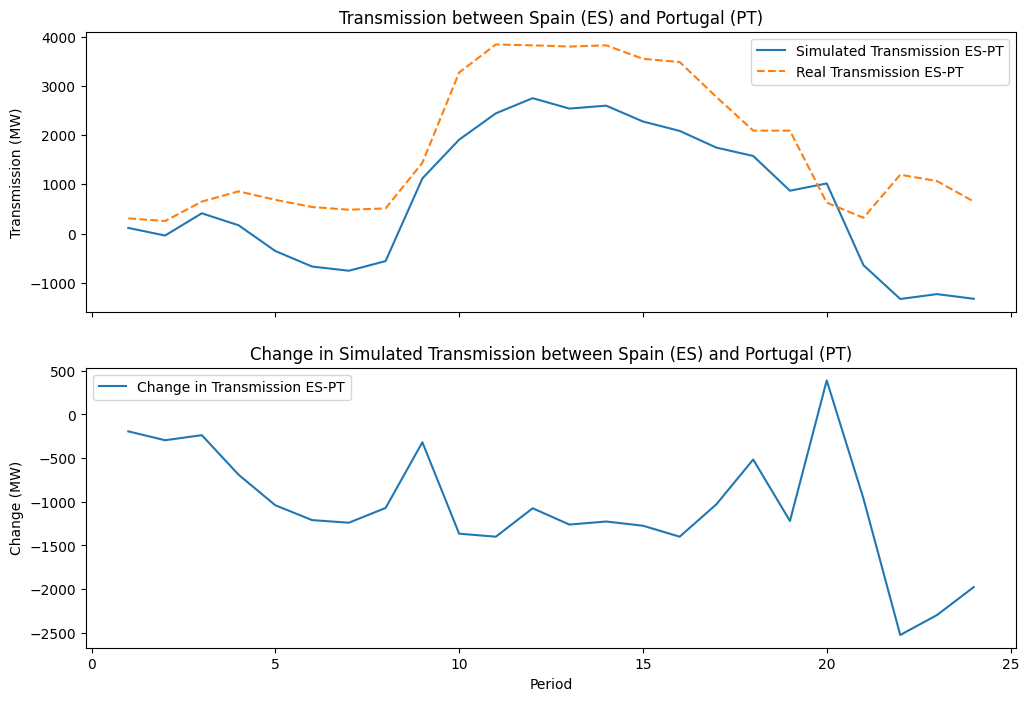

In [19]:
results_spain_portugal_transmissions = results_case_3["spain_portugal_transmissions"]
real_spain_portugal_transmissions = parse_capacidad_inter_file(
    CAPACIDAD_INTER_PBC_FILEPATH, "PT"
).eval(
    f"Transmision_ES_PT = {cols.FLOAT_EXPORT_CAPACITY_OCCUPATION} - {cols.FLOAT_IMPORT_CACACITY_OCCUPATION}"
)

transmissions_df = results_spain_portugal_transmissions.merge(
    real_spain_portugal_transmissions[[cols.INT_PERIOD, "Transmision_ES_PT"]],
    right_on=cols.INT_PERIOD,
    left_index=True,
    suffixes=("_simulated", "_real"),
)
transmissions_df["error_transmission"] = (
    transmissions_df["Transmision_ES_PT_simulated"]
    - transmissions_df["Transmision_ES_PT_real"]
).round(2)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
axes[0].plot(
    transmissions_df[cols.INT_PERIOD],
    transmissions_df["Transmision_ES_PT_simulated"],
    label="Simulated Transmission ES-PT",
)
axes[0].plot(
    transmissions_df[cols.INT_PERIOD],
    transmissions_df["Transmision_ES_PT_real"],
    label="Real Transmission ES-PT",
    linestyle="dashed",
)
axes[0].set_title("Transmission between Spain (ES) and Portugal (PT)")
axes[0].set_ylabel("Transmission (MW)")
axes[0].legend()

axes[1].plot(
    transmissions_df[cols.INT_PERIOD],
    transmissions_df["error_transmission"],
    label="Change in Transmission ES-PT",
)
axes[1].set_title(
    "Change in Simulated Transmission between Spain (ES) and Portugal (PT)"
)
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Change (MW)")
axes[1].legend()

# Use case 4: change prices of the group with most cleared energy 

## Choose among groups with most cleared energy

In [20]:
cleared_det_cab = results["cleared_det_cab"]
cleared_det_cab.groupby([cols.ID_UNIDAD, cols.CAT_BUY_SELL])[
    cols.FLOAT_CLEARED_POWER
].sum().sort_values(ascending=False).head(20)

/tmp/ipykernel_399804/1565459249.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cleared_det_cab.groupby([cols.ID_UNIDAD, cols.CAT_BUY_SELL])[


id_unidad  cat_buy_sell
ENDE01     C               72751.9
GEDPGC2    C               43932.9
GGNCOC1    C               36652.9
ICLIC01    C               34504.0
EDPSVD1    V               23931.7
EE21C01    C               23913.4
EGEDC01    C               20273.4
IGESC2     C               20124.7
HCGC01     C               18497.4
ENDPC2     C               17252.6
MIEU       V               16859.3
ALZ1       V               16030.1
GREPSC1    C               15512.1
IBCUC01    C               14941.7
ADOURO     V               13713.3
GSHEEC1    C               12758.7
MUEL       V               12502.8
TOTRM01    C               12151.6
DUER       V               11520.4
ASC2       V               11235.0
Name: float_cleared_power, dtype: float64

,id_order,int_period,int_num_block,int_num_suborder,int_num_excl_group,float_bid_price,float_bid_power,float_mav,float_mar,id_unidad,...,cat_bidding_zone,cat_order_type,float_bid_power_cumsum,id_individual_bid,id_block_order,id_sco,id_paradoxical_orders,float_bid_power_cumsum_by_country,float_cleared_power,_merge
7376,9726785,10,0,10,0,404.47,21.0,0.0,0.0,MUEL,...,ES,S,52996.5,10_V_9726785_10_0_0,<NA>,<NA>,NaN,41412.4,NaN,left_only
7377,9726785,10,0,11,0,404.57,21.0,0.0,0.0,MUEL,...,ES,S,53854.9,10_V_9726785_11_0_0,<NA>,<NA>,NaN,42248.6,NaN,left_only
7367,9726785,10,0,1,0,115.00,168.3,0.0,0.0,MUEL,...,ES,S,33129.6,10_V_9726785_1_0_0,<NA>,<NA>,NaN,27633.5,NaN,left_only
7368,9726785,10,0,2,0,115.24,168.3,0.0,0.0,MUEL,...,ES,S,33297.9,10_V_9726785_2_0_0,<NA>,<NA>,NaN,27801.8,NaN,left_only
7369,9726785,10,0,3,0,115.48,150.0,0.0,0.0,MUEL,...,ES,S,33447.9,10_V_9726785_3_0_0,<NA>,<NA>,NaN,27951.8,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7360,9726785,9,0,5,0,115.96,168.3,0.0,0.0,MUEL,...,ES,S,24561.9,9_V_9726785_5_0_0,<NA>,<NA>,NaN,19341.9,NaN,left_only
7361,9726785,9,0,6,0,116.20,150.0,0.0,0.0,MUEL,...,ES,S,24711.9,9_V_9726785_6_0_0,<NA>,<NA>,NaN,19491.9,NaN,left_only
7362,9726785,9,0,7,0,127.78,29.0,0.0,0.0,MUEL,...,ES,S,29764.5,9_V_9726785_7_0_0,<NA>,<NA>,NaN,22875.1,NaN,left_only
7363,9726785,9,0,8,0,129.11,29.0,0.0,0.0,MUEL,...,ES,S,30420.5,9_V_9726785_8_0_0,<NA>,<NA>,NaN,23531.1,NaN,left_only


/tmp/ipykernel_399804/1273256020.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
/tmp/ipykernel_399804/1273256020.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend()


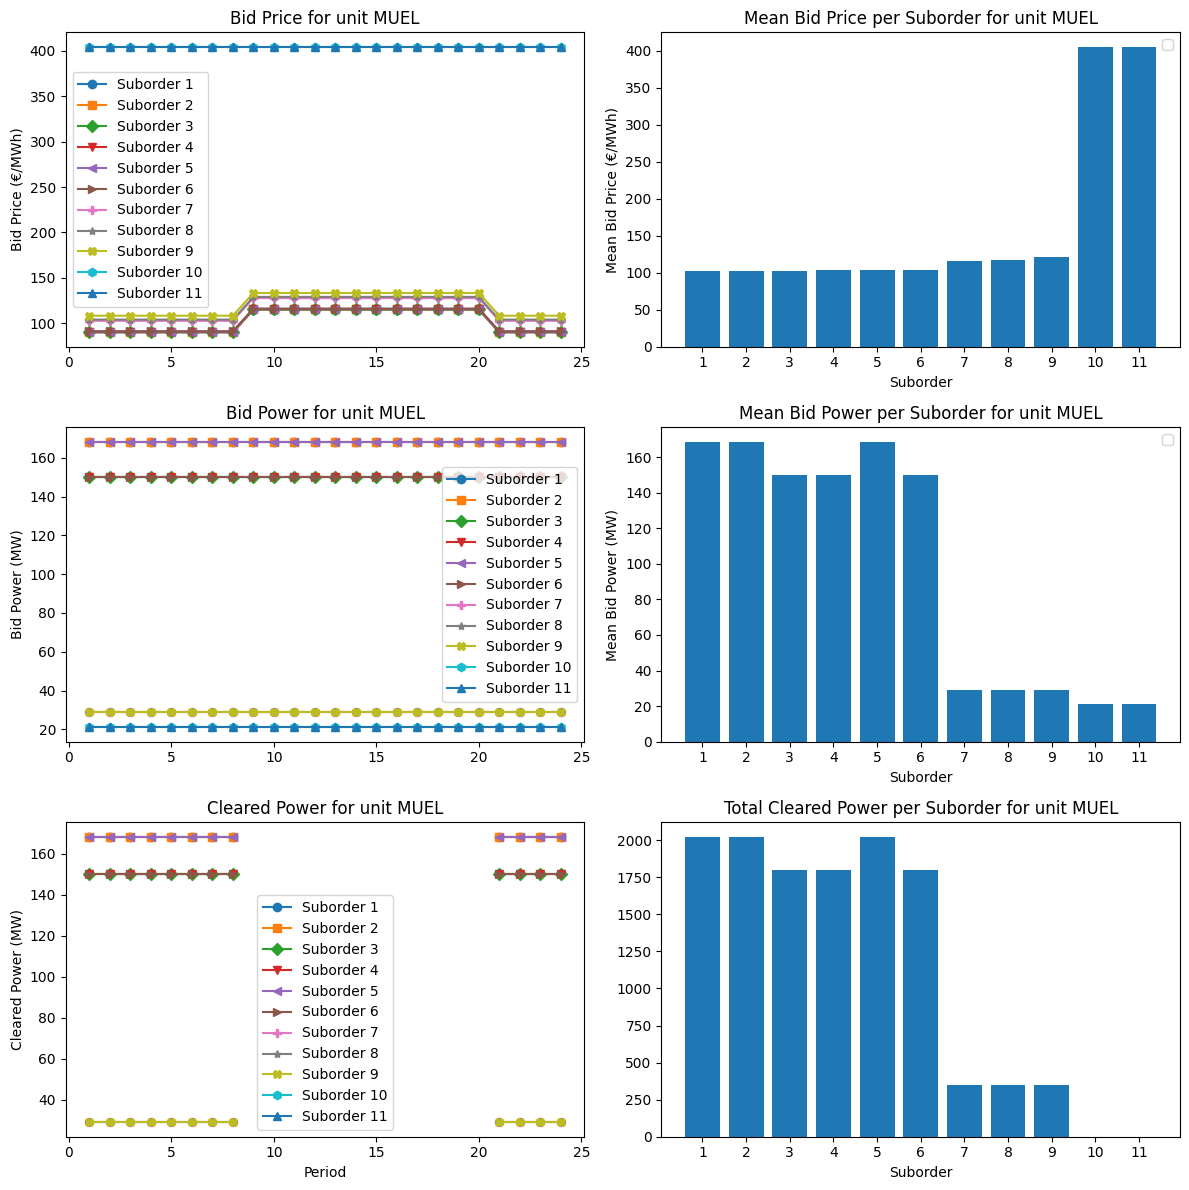

In [21]:
ANALYZED_ID_UNIDAD = "MUEL"
analyzed_id_order = cab_df.query(f"{cols.ID_UNIDAD} == @ANALYZED_ID_UNIDAD")[
    cols.ID_ORDER
].iloc[0]
unidad_bids = cleared_det_cab.query(f"{cols.ID_UNIDAD} == @ANALYZED_ID_UNIDAD").copy()

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
axes = axes.flatten()

display(unidad_bids)

markers = ["o", "s", "D", "v", "<", ">", "P", "*", "X", "h", "^", "H", "d", "p", "8"]


for idx, num_suborder in enumerate(
    unidad_bids[cols.INT_NUM_SUBORDER].sort_values().unique()
):
    suborder_bids = (
        unidad_bids.query(f"{cols.INT_NUM_SUBORDER} == @num_suborder")
        .copy()
        .sort_values(cols.INT_PERIOD)
    )

    axes[0].plot(
        suborder_bids[cols.INT_PERIOD],
        suborder_bids[cols.FLOAT_BID_PRICE],
        marker=markers[idx % len(markers)],
        label=f"Suborder {num_suborder}",
    )
    axes[2].plot(
        suborder_bids[cols.INT_PERIOD],
        suborder_bids[cols.FLOAT_BID_POWER],
        marker=markers[idx % len(markers)],
        label=f"Suborder {num_suborder}",
    )
    axes[4].plot(
        suborder_bids[cols.INT_PERIOD],
        suborder_bids[cols.FLOAT_CLEARED_POWER],
        marker=markers[idx % len(markers)],
        label=f"Suborder {num_suborder}",
    )

axes[0].set_title(f"Bid Price for unit {ANALYZED_ID_UNIDAD}")
axes[0].set_ylabel("Bid Price (€/MWh)")
axes[0].legend()
axes[2].set_title(f"Bid Power for unit {ANALYZED_ID_UNIDAD}")
axes[2].set_ylabel("Bid Power (MW)")
axes[2].legend()

mean_price_bid_per_suborder = (
    unidad_bids.groupby(cols.INT_NUM_SUBORDER)[cols.FLOAT_BID_PRICE].mean().sort_index()
)
axes[1].bar(
    mean_price_bid_per_suborder.index.astype(str),
    mean_price_bid_per_suborder.values,
)
axes[1].set_title(f"Mean Bid Price per Suborder for unit {ANALYZED_ID_UNIDAD}")
axes[1].set_xlabel("Suborder")
axes[1].set_ylabel("Mean Bid Price (€/MWh)")
axes[1].legend()

mean_power_bid_per_suborder = (
    unidad_bids.groupby(cols.INT_NUM_SUBORDER)[cols.FLOAT_BID_POWER].mean().sort_index()
)
axes[3].bar(
    mean_power_bid_per_suborder.index.astype(str),
    mean_power_bid_per_suborder.values,
)
axes[3].set_title(f"Mean Bid Power per Suborder for unit {ANALYZED_ID_UNIDAD}")
axes[3].set_xlabel("Suborder")
axes[3].set_ylabel("Mean Bid Power (MW)")
axes[3].legend()

axes[4].set_title(f"Cleared Power for unit {ANALYZED_ID_UNIDAD}")
axes[4].set_xlabel("Period")
axes[4].set_ylabel("Cleared Power (MW)")
axes[4].legend()

power_cleared_per_suborder = (
    unidad_bids.groupby(cols.INT_NUM_SUBORDER)[cols.FLOAT_CLEARED_POWER]
    .sum()
    .sort_index()
)

axes[5].bar(
    power_cleared_per_suborder.index.astype(str),
    power_cleared_per_suborder.values,
)
axes[5].set_title(f"Total Cleared Power per Suborder for unit {ANALYZED_ID_UNIDAD}")
axes[5].set_xlabel("Suborder")

plt.tight_layout()
plt.show()

## Create scenarios

In [22]:
PRICE_MULTIPLIERS = [1.0, 0.5, 1.1, 1.3, 1.5]

cab_df = parse_cab_file(CAB_FILEPATH)
det_df = parse_det_file(DET_FILEPATH)

det_and_cab_dfs = {}

for price_multiplier in PRICE_MULTIPLIERS:
    cab = cab_df.copy()
    det = det_df.copy()
    det.loc[
        det[cols.ID_ORDER] == analyzed_id_order, cols.FLOAT_BID_PRICE
    ] *= price_multiplier

    det_and_cab_dfs[price_multiplier] = (det, cab)

results_case_4 = {}

for price_multiplier, (det, cab) in det_and_cab_dfs.items():
    print(f"Running...")
    result = run_iberian_day_ahead_market_simulator(
        det=det,
        cab=cab,
        capacidad_inter_pbc=CAPACIDAD_INTER_PBC_FILEPATH,
        france_day_ahead_prices=france_day_ahead_prices,
        n_jobs=N_JOBS,
        solver_factory_type=SOLVER,
    )
    results_case_4[price_multiplier] = result

Periodo 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: data/DET/DET_20250621.1


21 2776.25
Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


...

/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


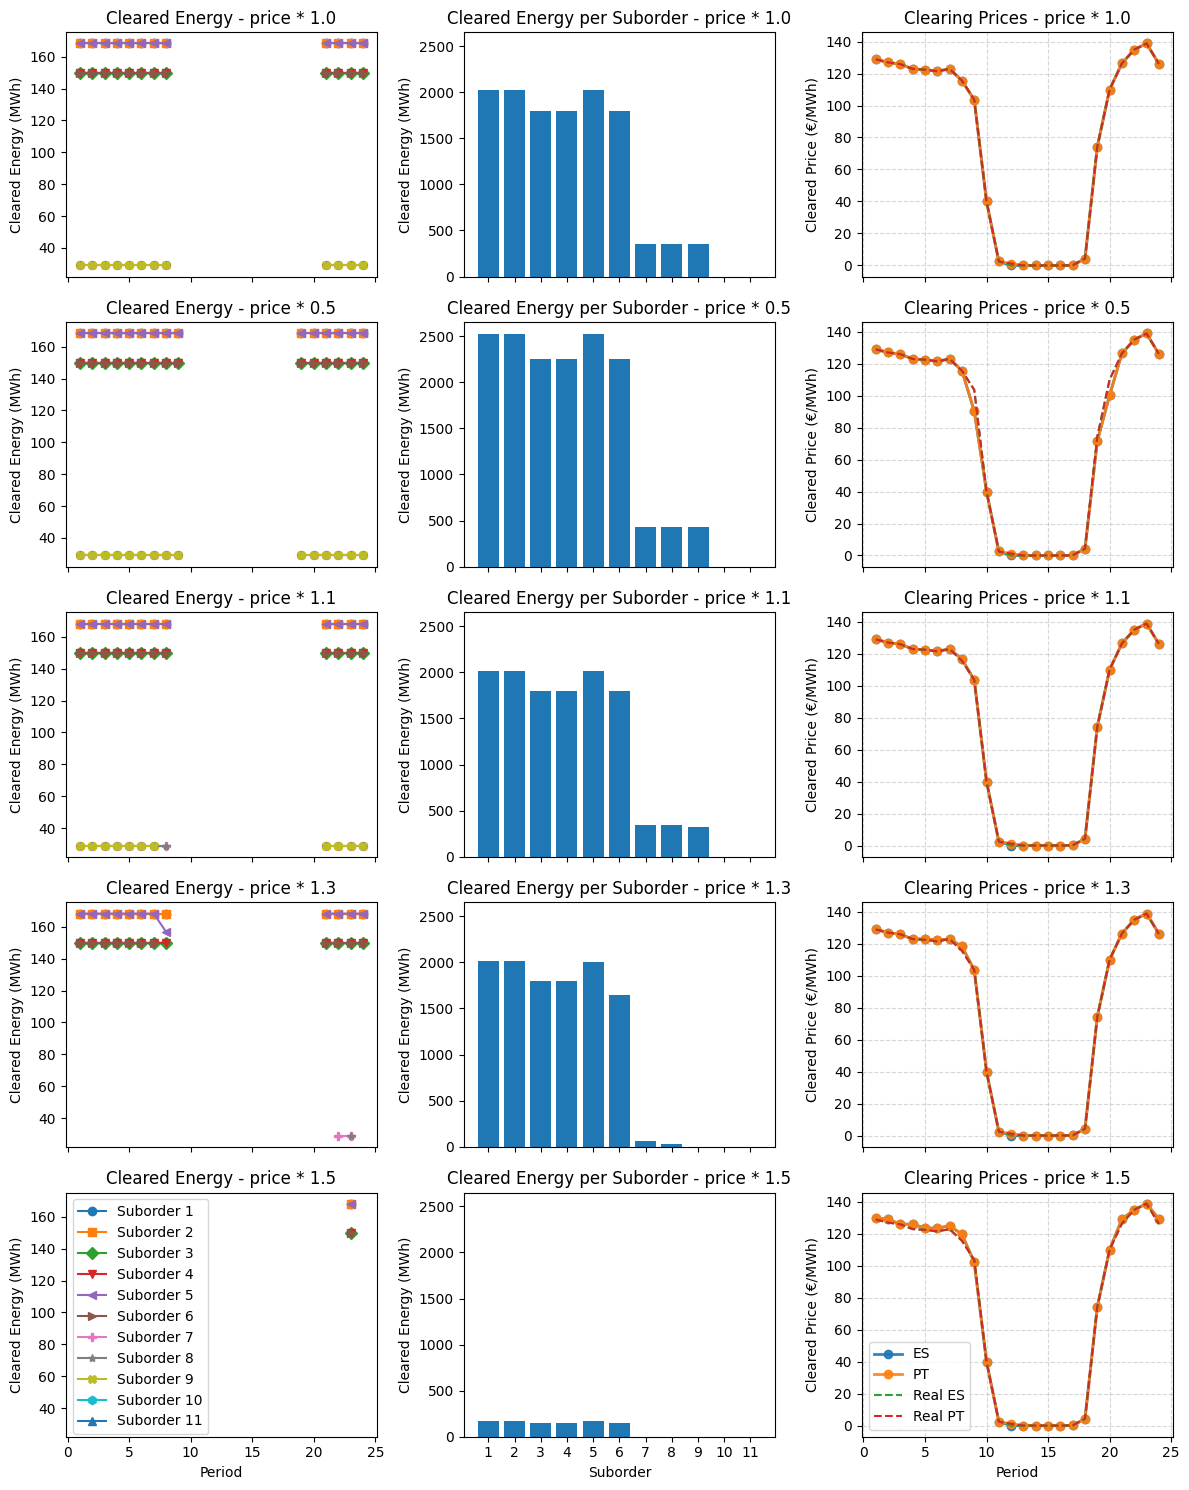

In [23]:
fig, axes = plt.subplots(
    nrows=len(results_case_4), ncols=3, figsize=(12, 15), sharex="col", sharey="col"
)

for idx, (price_multiplier, results) in enumerate(results_case_4.items()):
    cleared_det_cab = results["cleared_det_cab"]
    unidad_bids = cleared_det_cab.query(
        f"{cols.ID_UNIDAD} == @ANALYZED_ID_UNIDAD"
    ).copy()

    for idx_suborder, num_suborder in enumerate(
        unidad_bids[cols.INT_NUM_SUBORDER].sort_values().unique()
    ):
        suborder_bids = (
            unidad_bids.query(f"{cols.INT_NUM_SUBORDER} == @num_suborder")
            .copy()
            .sort_values(cols.INT_PERIOD)
        )

        axes[idx, 0].plot(
            suborder_bids[cols.INT_PERIOD],
            suborder_bids[cols.FLOAT_CLEARED_POWER],
            marker=markers[idx_suborder % len(markers)],
            label=f"Suborder {num_suborder}",
        )

    axes[idx, 0].set_title(f"Cleared Energy - price * {price_multiplier}")
    axes[idx, 0].set_ylabel("Cleared Energy (MWh)")

    power_cleared_per_suborder = (
        unidad_bids.groupby(cols.INT_NUM_SUBORDER)[cols.FLOAT_CLEARED_POWER]
        .sum()
        .sort_index()
    )

    axes[idx, 1].bar(
        power_cleared_per_suborder.index.astype(str),
        power_cleared_per_suborder.values,
    )
    axes[idx, 1].set_title(f"Cleared Energy per Suborder - price * {price_multiplier}")
    axes[idx, 1].set_ylabel("Cleared Energy (MWh)")

    plot_clearing_prices(
        results,
        ax=axes[idx, 2],
        title=f"Clearing Prices - price * {price_multiplier}",
        xlabel=None,
        legend=False,
    )
    # plot real clearing prices
    axes[idx, 2].plot(
        clearing_prices_df_es[cols.INT_PERIOD],
        clearing_prices_df_es[cols.FLOAT_CLEARED_PRICE + "_real"],
        label="Real ES",
        linestyle="dashed",
    )
    axes[idx, 2].plot(
        clearing_prices_df_pt[cols.INT_PERIOD],
        clearing_prices_df_pt[cols.FLOAT_CLEARED_PRICE + "_real"],
        label="Real PT",
        linestyle="dashed",
    )

last_index = len(results_case_4) - 1
axes[last_index, 2].legend()
axes[last_index, 0].legend()
axes[last_index, 1].set_xlabel("Suborder")
axes[last_index, 0].set_xlabel("Period")
axes[last_index, 2].set_xlabel("Period")

plt.tight_layout()
plt.show()

# Case study 5: change wind production and see how it affects the clearing process

In [24]:
results = run_iberian_day_ahead_market_simulator(
    det=DET_FILEPATH,
    cab=CAB_FILEPATH,
    capacidad_inter_pbc=CAPACIDAD_INTER_PBC_FILEPATH,
    france_day_ahead_prices=france_day_ahead_prices,
    n_jobs=N_JOBS,
    solver_factory_type=SOLVER,
)

cleared_det_cab = results["cleared_det_cab"]

Periodo 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: data/DET/DET_20250621.1


21 2776.25


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


In [25]:
unidades_list = pd.read_excel("data/LISTA_UNIDADES.XLS", skiprows=3).iloc[:, :7]
unidades_list["TECNOLOGÍA"].sort_values().unique()

TECNOLOGIA_EOLICA = ["RE Mercado Eólica", "RE Mercado Eólica Marina"]

id_unidades_wind_power = unidades_list.query(
    f"TECNOLOGÍA in @TECNOLOGIA_EOLICA"
).copy()["CODIGO"]
id_orders_wind_power = cab_df.query(f"{cols.ID_UNIDAD} in @id_unidades_wind_power")[
    cols.ID_ORDER
].unique()

cleared_det_cab_wind_power = cleared_det_cab.query(
    f"{cols.ID_UNIDAD} in @id_unidades_wind_power"
).copy()

WARNING *** file size (602379) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


Text(0.5, 0, 'Period')

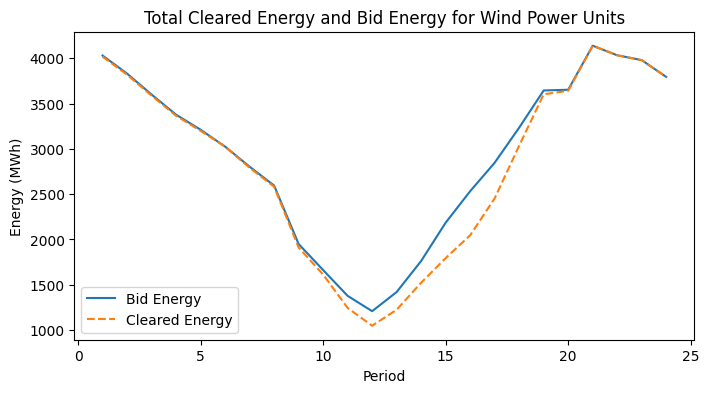

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

wind_power_cleared_power_per_period = (
    cleared_det_cab_wind_power.groupby(cols.INT_PERIOD)[cols.FLOAT_CLEARED_POWER]
    .sum()
    .sort_index()
)
wind_power_bid_power_per_period = (
    cleared_det_cab_wind_power.groupby(cols.INT_PERIOD)[cols.FLOAT_BID_POWER]
    .sum()
    .sort_index()
)

ax.plot(
    wind_power_bid_power_per_period.index,
    wind_power_bid_power_per_period.values,
    label="Bid Energy",
)
ax.plot(
    wind_power_cleared_power_per_period.index,
    wind_power_cleared_power_per_period.values,
    label="Cleared Energy",
    linestyle="dashed",
)
ax.set_title("Total Cleared Energy and Bid Energy for Wind Power Units")
ax.set_ylabel("Energy (MWh)")
ax.legend()

ax.set_xlabel("Period")

## Create scenarios

In [27]:
VOLUME_MULTIPLIERS = [1, 0.5, 0.75, 1.5, 2.0]

In [28]:
cab_df = parse_cab_file(CAB_FILEPATH)
det_df = parse_det_file(DET_FILEPATH)
real_clearing_prices = parse_marginalpdbc_file(MARGINALPDBC_FILEPATH)
real_clearing_prices_es = real_clearing_prices.query(
    f"{cols.CAT_BIDDING_ZONE} == 'ES'"
).copy()
real_clearing_prices_pt = real_clearing_prices.query(
    f"{cols.CAT_BIDDING_ZONE} == 'PT'"
).copy()

det_and_cab_dfs_case_5 = {}

for volume_multiplier in VOLUME_MULTIPLIERS:
    cab = cab_df.copy()
    det = det_df.copy()
    cab.loc[cab[cols.ID_ORDER].isin(id_orders_wind_power), cols.FLOAT_MAX_POWER] *= (
        volume_multiplier * 2
    )
    det.loc[
        det[cols.ID_ORDER].isin(id_orders_wind_power), cols.FLOAT_BID_POWER
    ] *= volume_multiplier

    det_and_cab_dfs_case_5[volume_multiplier] = (det, cab)

results_case_5 = {}

for volume_multiplier, (det, cab) in det_and_cab_dfs_case_5.items():
    print(f"Running...")
    result = run_iberian_day_ahead_market_simulator(
        det=det,
        cab=cab,
        capacidad_inter_pbc=CAPACIDAD_INTER_PBC_FILEPATH,
        france_day_ahead_prices=france_day_ahead_prices,
        n_jobs=N_JOBS,
        solver_factory_type=SOLVER,
    )
    results_case_5[volume_multiplier] = result

Periodo 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: data/DET/DET_20250621.1


21 2776.25
Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


...

/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


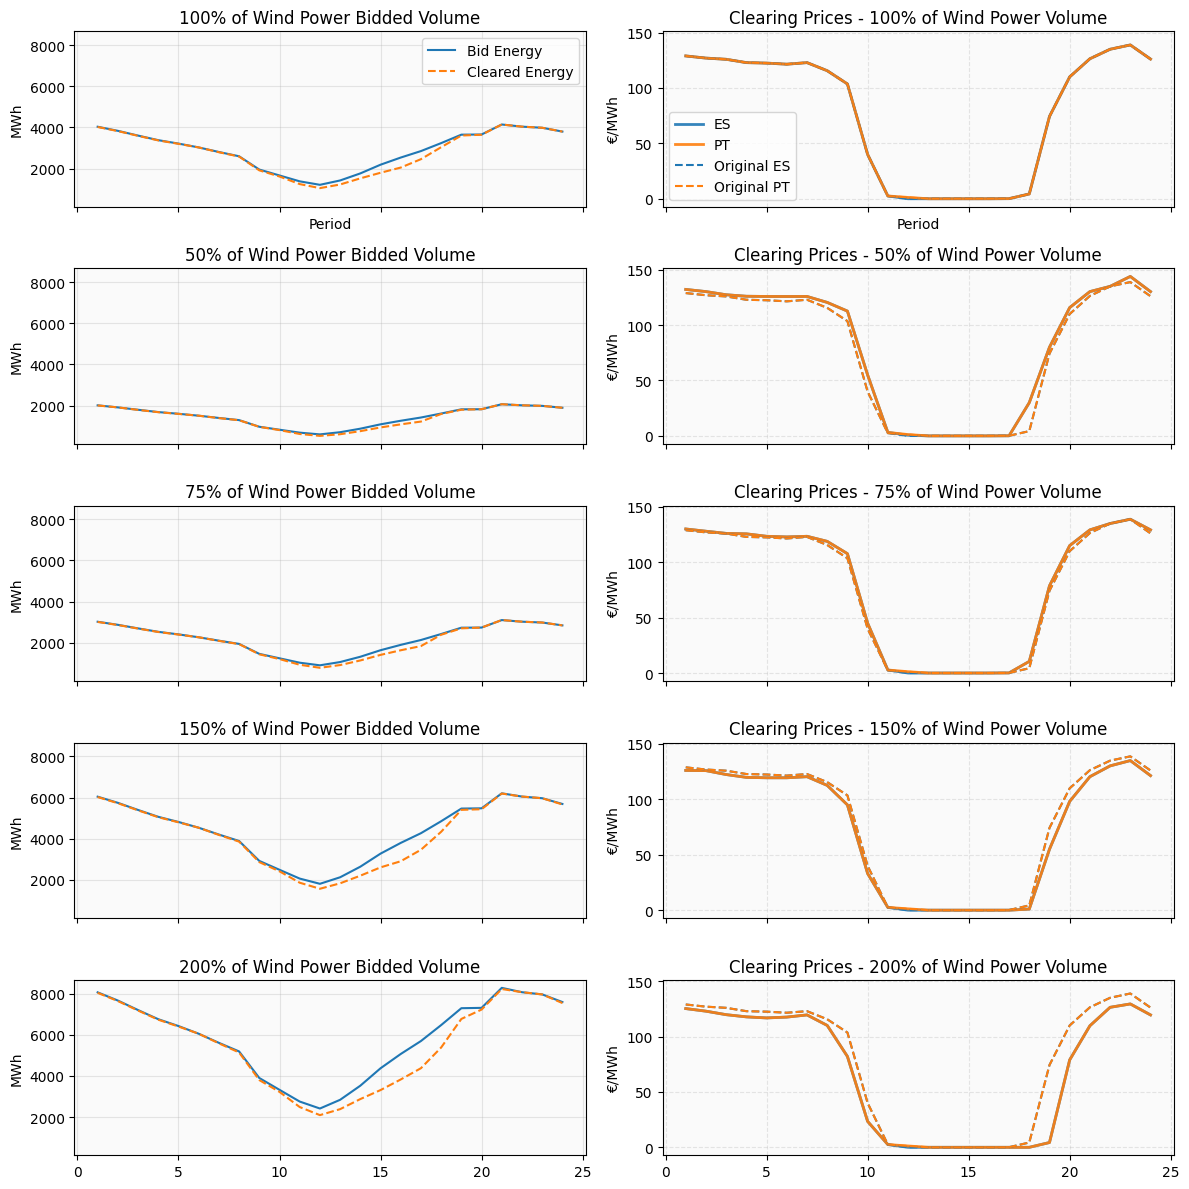

In [29]:
fig, axes = plt.subplots(
    nrows=len(VOLUME_MULTIPLIERS), ncols=2, figsize=(12, 12), sharex="col", sharey="col"
)

tabpalette = plt.get_cmap("tab10")

for idx, (volume_multiplier, results) in enumerate(results_case_5.items()):
    cleared_det_cab = results["cleared_det_cab"]
    cleared_det_cab_wind_power = cleared_det_cab.query(
        f"{cols.ID_UNIDAD} in @id_unidades_wind_power"
    ).copy()

    wind_power_cleared_power_per_period = (
        cleared_det_cab_wind_power.groupby(cols.INT_PERIOD)[cols.FLOAT_CLEARED_POWER]
        .sum()
        .sort_index()
    )
    wind_power_bid_power_per_period = (
        cleared_det_cab_wind_power.groupby(cols.INT_PERIOD)[cols.FLOAT_BID_POWER]
        .sum()
        .sort_index()
    )

    axes[idx, 0].plot(
        wind_power_bid_power_per_period.index,
        wind_power_bid_power_per_period.values,
        label="Bid Energy",
    )
    axes[idx, 0].plot(
        wind_power_cleared_power_per_period.index,
        wind_power_cleared_power_per_period.values,
        label="Cleared Energy",
        linestyle="dashed",
    )
    axes[idx, 0].set_title(
        f"{volume_multiplier * 100:.0f}% of Wind Power Bidded Volume"
    )
    axes[idx, 0].set_ylabel("MWh")

    plot_clearing_prices(
        results,
        ax=axes[idx, 1],
        title=f"Clearing Prices - {volume_multiplier * 100:.0f}% of Wind Power Volume",
        xlabel=None,
        legend=False,
        ylabel="€/MWh",
        marker="None",
    )
    # plot real clearing prices
    axes[idx, 1].plot(
        real_clearing_prices_es[cols.INT_PERIOD],
        real_clearing_prices_es[cols.FLOAT_CLEARED_PRICE],
        label="Original ES",
        color=tabpalette(0),
        # marker="x",
        markersize=12,
        linestyle="--",
    )
    axes[idx, 1].plot(
        real_clearing_prices_pt[cols.INT_PERIOD],
        real_clearing_prices_pt[cols.FLOAT_CLEARED_PRICE],
        label="Original PT",
        color=tabpalette(1),
        # marker="x",
        markersize=12,
        linestyle="--",
    )

    axes[idx, 0].set_facecolor("#fafafa")
    axes[idx, 1].set_facecolor("#fafafa")
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 1].grid(True, alpha=0.3)

# last_index = len(results_case_5) - 1
axes[0, 1].legend()
axes[0, 0].legend()
axes[0, 0].set_xlabel("Period")
axes[0, 1].set_xlabel("Period")

plt.tight_layout()
plt.show()

# Case study 6: change solar production and see how it affects the clearing process

In [30]:
unidades_list = pd.read_excel("data/LISTA_UNIDADES.XLS", skiprows=3).iloc[:, :7]
unidades_list["TECNOLOGÍA"].sort_values().unique()

TECNOLOGIA_SOLAR = ["RE Mercado Solar Fotovoltáica", "RE Mercado Solar Térmica"]

id_unidades_solar = unidades_list.query(f"TECNOLOGÍA in @TECNOLOGIA_SOLAR").copy()[
    "CODIGO"
]
id_orders_solar = cab_df.query(f"{cols.ID_UNIDAD} in @id_unidades_solar")[
    cols.ID_ORDER
].unique()

cleared_det_cab_solar = cleared_det_cab.query(
    f"{cols.ID_UNIDAD} in @id_unidades_solar"
).copy()

WARNING *** file size (602379) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


Text(0.5, 0, 'Period')

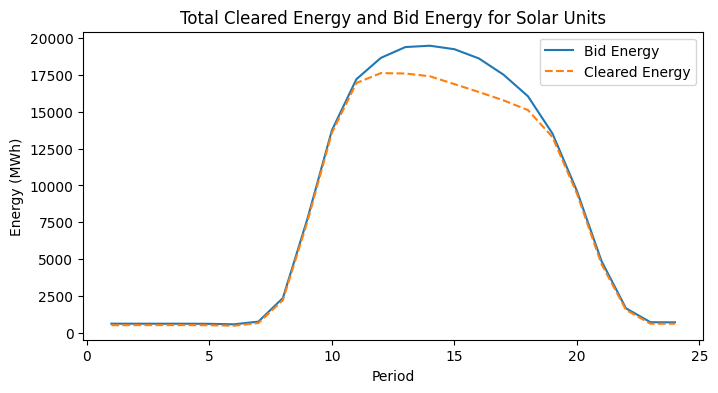

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

solar_cleared_power_per_period = (
    cleared_det_cab_solar.groupby(cols.INT_PERIOD)[cols.FLOAT_CLEARED_POWER]
    .sum()
    .sort_index()
)
solar_bid_power_per_period = (
    cleared_det_cab_solar.groupby(cols.INT_PERIOD)[cols.FLOAT_BID_POWER]
    .sum()
    .sort_index()
)

ax.plot(
    solar_bid_power_per_period.index,
    solar_bid_power_per_period.values,
    label="Bid Energy",
)
ax.plot(
    solar_cleared_power_per_period.index,
    solar_cleared_power_per_period.values,
    label="Cleared Energy",
    linestyle="dashed",
)
ax.set_title("Total Cleared Energy and Bid Energy for Solar Units")
ax.set_ylabel("Energy (MWh)")
ax.legend()

ax.set_xlabel("Period")

## Create scenarios

In [32]:
VOLUME_MULTIPLIERS = [0.5, 0.75, 1.5, 2.0]

In [33]:
cab_df = parse_cab_file(CAB_FILEPATH)
det_df = parse_det_file(DET_FILEPATH)

det_and_cab_dfs_case_6 = {}

for volume_multiplier in VOLUME_MULTIPLIERS:
    cab = cab_df.copy()
    det = det_df.copy()
    cab.loc[cab[cols.ID_ORDER].isin(id_orders_solar), cols.FLOAT_MAX_POWER] *= (
        volume_multiplier * 2
    )
    det.loc[
        det[cols.ID_ORDER].isin(id_orders_solar), cols.FLOAT_BID_POWER
    ] *= volume_multiplier

    det_and_cab_dfs_case_6[volume_multiplier] = (det, cab)

results_case_6 = {}

for volume_multiplier, (det, cab) in det_and_cab_dfs_case_6.items():
    print(f"Running...")
    result = run_iberian_day_ahead_market_simulator(
        det=det,
        cab=cab,
        capacidad_inter_pbc=CAPACIDAD_INTER_PBC_FILEPATH,
        france_day_ahead_prices=france_day_ahead_prices,
        n_jobs=N_JOBS,
        solver_factory_type=SOLVER,
    )
    results_case_6[volume_multiplier] = result

Periodo 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: data/DET/DET_20250621.1


21 2776.25
Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


Running...


/home/einsunza/anaconda3/envs/final-paper-test/lib/python3.10/site-packages/iberian_day_ahead_market_simulator/clearing_process.py:699: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iterations_df = pd.concat([iterations_df] + results, ignore_index=True)


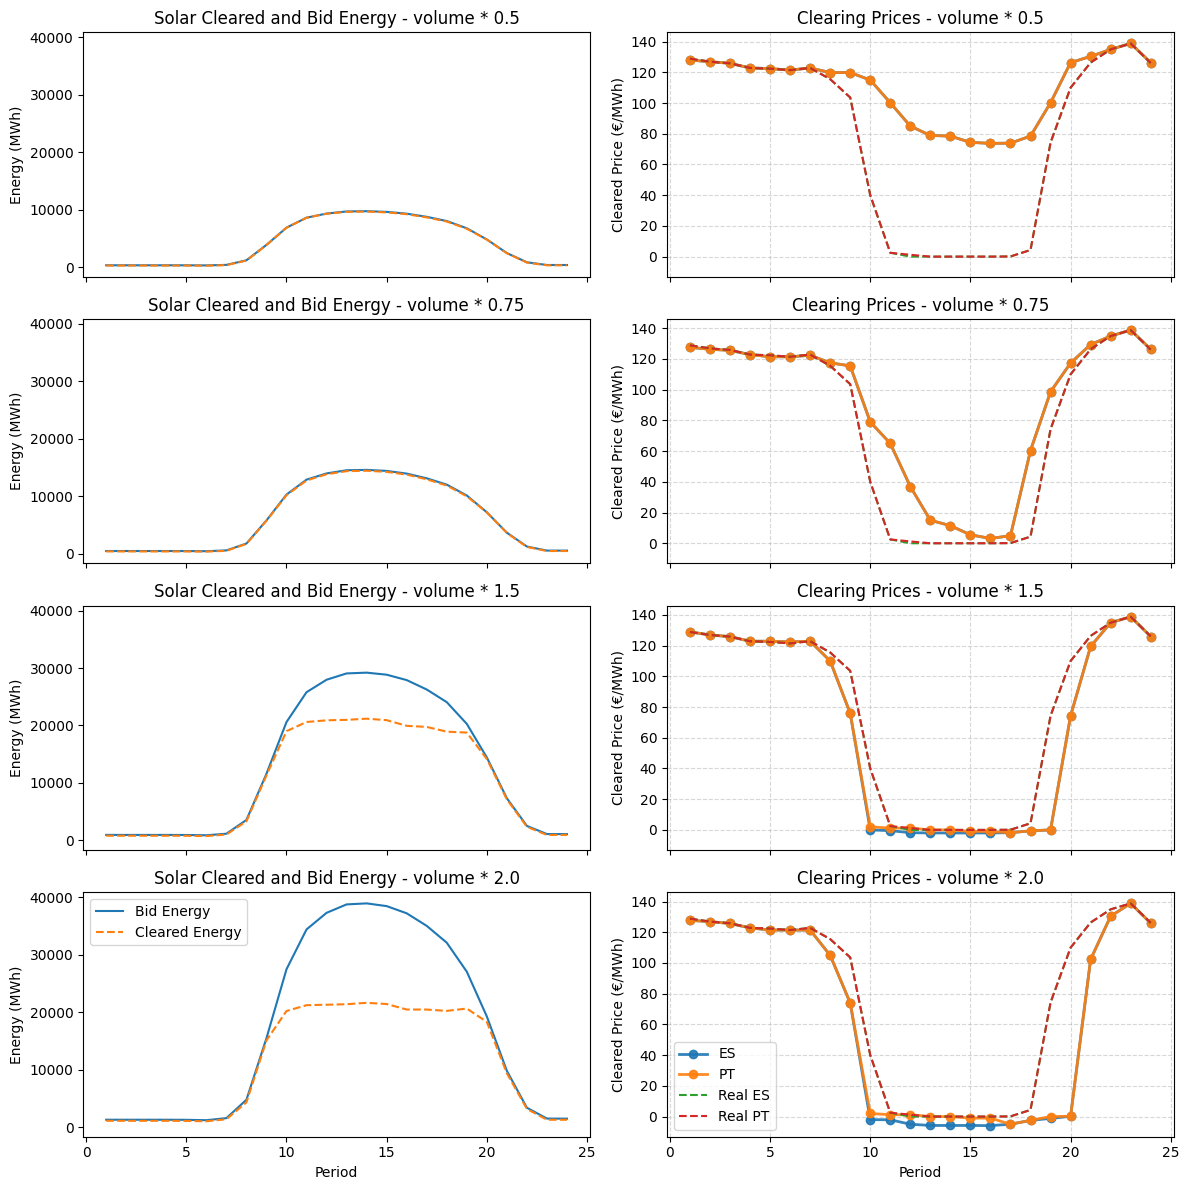

In [34]:
fig, axes = plt.subplots(
    nrows=len(VOLUME_MULTIPLIERS), ncols=2, figsize=(12, 12), sharex="col", sharey="col"
)

for idx, (volume_multiplier, results) in enumerate(results_case_6.items()):
    cleared_det_cab = results["cleared_det_cab"]
    cleared_det_cab_solar = cleared_det_cab.query(
        f"{cols.ID_UNIDAD} in @id_unidades_solar"
    ).copy()

    solar_cleared_power_per_period = (
        cleared_det_cab_solar.groupby(cols.INT_PERIOD)[cols.FLOAT_CLEARED_POWER]
        .sum()
        .sort_index()
    )
    solar_bid_power_per_period = (
        cleared_det_cab_solar.groupby(cols.INT_PERIOD)[cols.FLOAT_BID_POWER]
        .sum()
        .sort_index()
    )

    axes[idx, 0].plot(
        solar_bid_power_per_period.index,
        solar_bid_power_per_period.values,
        label="Bid Energy",
    )
    axes[idx, 0].plot(
        solar_cleared_power_per_period.index,
        solar_cleared_power_per_period.values,
        label="Cleared Energy",
        linestyle="dashed",
    )
    axes[idx, 0].set_title(
        f"Solar Cleared and Bid Energy - volume * {volume_multiplier}"
    )
    axes[idx, 0].set_ylabel("Energy (MWh)")

    plot_clearing_prices(
        results,
        ax=axes[idx, 1],
        title=f"Clearing Prices - volume * {volume_multiplier}",
        xlabel=None,
        legend=False,
    )
    # plot real clearing prices
    axes[idx, 1].plot(
        clearing_prices_df_es[cols.INT_PERIOD],
        clearing_prices_df_es[cols.FLOAT_CLEARED_PRICE + "_real"],
        label="Real ES",
        linestyle="dashed",
    )
    axes[idx, 1].plot(
        clearing_prices_df_pt[cols.INT_PERIOD],
        clearing_prices_df_pt[cols.FLOAT_CLEARED_PRICE + "_real"],
        label="Real PT",
        linestyle="dashed",
    )

last_index = len(results_case_6) - 1
axes[last_index, 1].legend()
axes[last_index, 0].legend()
axes[last_index, 0].set_xlabel("Period")
axes[last_index, 1].set_xlabel("Period")

plt.tight_layout()
plt.show()